In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from simulation import Simulation
from algorithms.methods import *
from utils.read_data import *
from utils.postprocess import *

import random
random.seed(10)
pd.set_option('display.precision', 2)

In [14]:
#import mnist
from sklearn.datasets import load_digits
digits = load_digits()
X = digits.data
y = digits.target

In [3]:
X,y = read_s_dataset(2)
#plot_clusters_2d(X, y)

/Users/yi/Desktop/Essay/utils/read_data.py:6: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  X = pd.read_csv(f'data/s-originals/s{s}.txt', header=None, sep='   ')
/Users/yi/Desktop/Essay/utils/read_data.py:7: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  y = pd.read_csv(


# old

{'WCSS': np.float64(13279233523688.96), 'ARI': 0.9374771208934591, 'NMI': 0.9462508417022361, 'Purity': np.float64(0.9698), 'Silhouette': 0.6260918918388568}


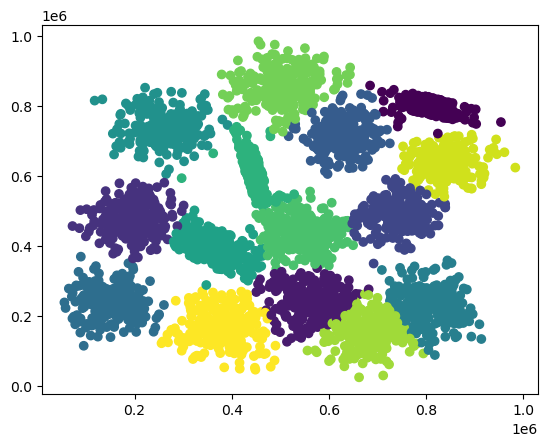

In [4]:
kmeans = KMeans(n_clusters=15, n_init=1).fit(X)
print(evaluation_summary(X, kmeans.cluster_centers_, y))
plt.scatter(X[:,0], X[:,1], c=kmeans.labels_)

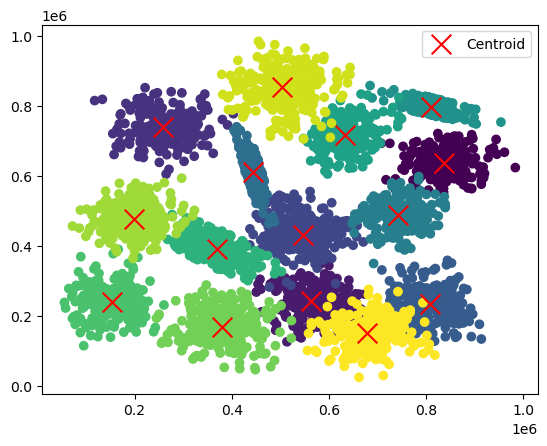

In [5]:
plot_clusters_2d(X,y, kmeans.cluster_centers_)

In [28]:
def visualize_centers(clients_centers, server_centers, centralized_centers):
    df = pd.concat({'Client Centers': pd.DataFrame(clients_centers),
                    'Server Centers': pd.DataFrame(server_centers),
                    'Centralized': pd.DataFrame(centralized_centers)
                    },axis=0).reset_index()
    fig = px.scatter(df, x=0, y=1, color='level_0', title='Server Agg Centers vs Centralized Centers', labels={'level_0': 'Type'})
    return fig

In [53]:
from simulation import Simulation
N_CLIENT = 10
K_CLIENT = 15
K_SERVER = 15
SNR_DB = 10
N_RUNS = 10
sim = Simulation(X, y, N_CLIENT, K_CLIENT, K_SERVER, N_RUNS, noise='gaussian', snr_db=SNR_DB, aggregation=['kmeans','trimmed_kmeans'])
sim.run()

Run: 1/10 {'WCSS': np.float64(59681436544783.234), 'ARI': 0.6177178713268832, 'NMI': 0.7877357030880183, 'Purity': np.float64(0.7112), 'Silhouette': 0.3650402673655766}
Run: 2/10 {'WCSS': np.float64(66635429126113.36), 'ARI': 0.537513911385084, 'NMI': 0.746654043623146, 'Purity': np.float64(0.645), 'Silhouette': 0.3038488607448906}
Run: 3/10 {'WCSS': np.float64(62067558876469.875), 'ARI': 0.569695608027571, 'NMI': 0.7613684062877681, 'Purity': np.float64(0.6248), 'Silhouette': 0.3465465386366864}
Run: 4/10 {'WCSS': np.float64(47015866093952.125), 'ARI': 0.6723476432933351, 'NMI': 0.8148387398339029, 'Purity': np.float64(0.7462), 'Silhouette': 0.41478839688296304}
Run: 5/10 {'WCSS': np.float64(55262536364520.19), 'ARI': 0.6712011027829292, 'NMI': 0.8313825122707562, 'Purity': np.float64(0.733), 'Silhouette': 0.40706034609622627}
Run: 6/10 {'WCSS': np.float64(78613760224521.7), 'ARI': 0.574741874310815, 'NMI': 0.7744322589740427, 'Purity': np.float64(0.6236), 'Silhouette': 0.351830266255

              kmeans  trimmed_kmeans  Centralized K-Means
WCSS        6.93e+13        6.50e+13             1.37e+13
ARI         5.50e-01        5.75e-01             9.29e-01
NMI         7.55e-01        7.67e-01             9.42e-01
Purity      6.41e-01        6.55e-01             9.63e-01
Silhouette  2.89e-01        3.29e-01             6.21e-01


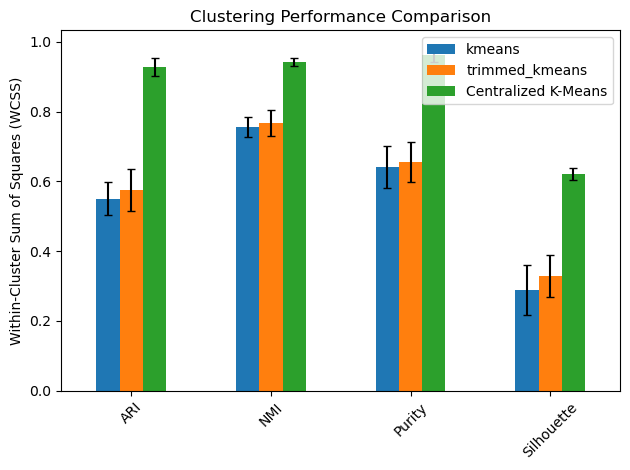

In [54]:
print(sim.stats['mean'])
sim.plot_summary()

Visualise centers

In [37]:
i = 0
visualize_centers(sim.clients_centers[i], sim.server_centers['kmeans'][i], sim.centralized_centers[i])

# Exprimental

In [14]:
def tsne_visualization(X, y, clients_centers, server_centers, centralized_centers):
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, random_state=0, perplexity=10)
    X_embedded = tsne.fit_transform(X)
    clients_embedded = tsne.fit_transform(clients_centers)
    #server_embedded = tsne.fit_transform(server_centers)
    #centralized_embedded = tsne.fit_transform(centralized_centers)

    plt.figure(figsize=(12, 8))
    plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y, alpha=0.5, label='Data')
    plt.scatter(clients_embedded[:, 0], clients_embedded[:, 1], c='red', marker='x', label='Client Centers')
    #plt.scatter(server_embedded[:, 0], server_embedded[:, 1], c='green', marker='x', label='Server Centers')
    #plt.scatter(centralized_embedded[:, 0], centralized_embedded[:, 1], c='blue', marker='x', label='Centralized Centers')
    plt.legend()
    plt.title('t-SNE Visualization of Clusters and Centers')
    plt.show()

In [16]:
def trimmed_kmeans(X, n_clusters, trim_ratio=0.1, max_iter=300, tol=1e-4, random_state=None):
    """
    Trimmed K-Means clustering algorithm.
    
    Parameters:
    -----------
    X : array-like, shape (n_samples, n_features)
        Input data
    n_clusters : int
        Number of clusters to form
    trim_ratio : float, default=0.1
        Proportion of points to trim (remove) in each iteration
    max_iter : int, default=300
        Maximum number of iterations
    tol : float, default=1e-4
        Tolerance for convergence
    random_state : int or None, default=None
        Random seed for initialization
        
    Returns:
    --------
    cluster_centers : array, shape (n_clusters, n_features)
        Final cluster centers
    """
    n_samples, n_features = X.shape
    n_trim = int(n_samples * trim_ratio)
    
    # Initialize centers using k-means++ initialization
    rng = np.random.default_rng(random_state)
    
    # Select first center randomly
    centers = np.zeros((n_clusters, n_features))
    centers[0] = X[rng.integers(n_samples)]
    
    # K-means++ initialization for remaining centers
    for i in range(1, n_clusters):
        # Compute distances to nearest center for each point
        distances = np.min(np.sum((X[:, np.newaxis] - centers[:i]) ** 2, axis=2), axis=1)
        # Sample next center with probability proportional to distance squared
        probs = distances / distances.sum()
        centers[i] = X[rng.choice(n_samples, p=probs)]
    
    for iteration in range(max_iter):
        # Compute distances from each point to each center
        distances = np.sum((X[:, np.newaxis] - centers) ** 2, axis=2)
        
        # Assign each point to nearest center
        labels = np.argmin(distances, axis=1)
        
        # Compute distances to assigned centers
        point_distances = distances[np.arange(n_samples), labels]
        
        # Sort points by distance and trim farthest points
        sorted_indices = np.argsort(point_distances)
        keep_indices = sorted_indices[:-n_trim] if n_trim > 0 else sorted_indices
        
        # Update centers using only kept points
        new_centers = np.zeros_like(centers)
        for k in range(n_clusters):
            cluster_points = X[(labels == k) & np.isin(np.arange(n_samples), keep_indices)]
            if len(cluster_points) > 0:
                new_centers[k] = cluster_points.mean(axis=0)
            else:
                # If cluster becomes empty, reinitialize with a random kept point
                new_centers[k] = X[keep_indices[rng.integers(len(keep_indices))]]
        
        # Check for convergence
        center_shift = np.sqrt(np.sum((new_centers - centers) ** 2))
        centers = new_centers
        
        if center_shift < tol:
            break
    
    return centers

In [17]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def mean_shift_filtering(X, k=10, iterations=1, include_self=False):
    """Mean shift filtering using k-nearest neighbors."""
    X = np.asarray(X)
    n_samples = X.shape[0]
    
    # Ensure k is not larger than number of samples
    if k > n_samples:
        raise ValueError(f"k ({k}) cannot exceed number of samples ({n_samples})")
    if not include_self and k > n_samples - 1:
        raise ValueError(f"Without self, k cannot exceed n_samples-1 ({n_samples-1})")
    
    X_current = X.copy()
    
    for _ in range(iterations):
        # Build nearest neighbors model on the current positions
        # Use algorithm='auto' (usually kd_tree or ball_tree for low/medium dims)
        nbrs = NearestNeighbors(n_neighbors=k, algorithm='auto')
        nbrs.fit(X_current)
        
        # Find indices of k nearest neighbors for each point
        # distances, indices = nbrs.kneighbors(X_current)
        indices = nbrs.kneighbors(X_current, return_distance=False)
        
        # For each point, compute the mean of its neighbors
        new_points = []
        for i in range(n_samples):
            neighbor_idxs = indices[i]
            # If include_self is False, ensure we remove the point itself
            if not include_self:
                # neighbor_idxs may contain i; remove it
                neighbor_idxs = neighbor_idxs[neighbor_idxs != i]
                # If after removal we have fewer than k neighbors (shouldn't happen by check)
                if len(neighbor_idxs) == 0:
                    # Fallback: keep the point unchanged
                    new_points.append(X_current[i])
                    continue
            mean_vec = np.mean(X_current[neighbor_idxs], axis=0)
            new_points.append(mean_vec)
        
        X_current = np.array(new_points)
    
    return X_current

def isolation_filtring(X, alpha=0.1, k=10):
    # remove top alpha% farthest points from their neighbors
    nbrs = NearestNeighbors(n_neighbors=k, algorithm='auto')
    nbrs.fit(X)
    distances, indices = nbrs.kneighbors(X)
    # Compute average distance to neighbors for each point
    avg_distances = np.mean(distances, axis=1)
    # Determine threshold for top alpha% farthest points
    threshold = np.percentile(avg_distances, 100 * (1 - alpha))
    # Filter out points that are farther than the threshold
    filtered_indices = np.where(avg_distances <= threshold)[0]
    return X[filtered_indices]

### Without filtering

In [18]:
agg_centers = kmeans(sim.clients_centers[0], n_clusters=K_SERVER)
#agg_centers = trimmed_kmeans(sim.clients_centers[0], n_clusters=K_SERVER, trim_ratio=0.0001)
#agg_centers =  HDBSCAN(min_cluster_size=5).fit_predict(sim.clients_centers[0])
evaluation_summary(X, agg_centers, y)

{'WCSS': np.float64(14578651319945.023),
 'ARI': 0.9224117947941101,
 'NMI': 0.9350577154558195,
 'Purity': np.float64(0.9624),
 'Silhouette': 0.6225862865108814}

In [19]:
visualize_centers(sim.clients_centers[0], agg_centers, sim.centralized_centers[0])

### With filtering

In [20]:
filtered = mean_shift_filtering(sim.clients_centers[0], k=15, iterations=1, include_self=True)
#filtered = isolation_filtring(sim.clients_centers[0], alpha=0.1, k=10)
agg_centers = kmeans(filtered, n_clusters=K_SERVER)
evaluation_summary(X, agg_centers, y)

{'WCSS': np.float64(14964630187162.914),
 'ARI': 0.9154772314405195,
 'NMI': 0.9311716897831844,
 'Purity': np.float64(0.9586),
 'Silhouette': 0.6191027933362535}

In [21]:
visualize_centers(filtered, sim.clients_centers[0], sim.centralized_centers[0])

In [22]:
#agg_centers = kmeans(sim.clients_centers[0], n_clusters=K_SERVER)
agg_centers = trimmed_kmeans(sim.clients_centers[0], n_clusters=K_SERVER, trim_ratio=0.5)
#agg_centers =  HDBSCAN(min_cluster_size=5).fit_predict(sim.clients_centers[0])

evaluation_summary(X, agg_centers, y)

{'WCSS': np.float64(29088979482765.5),
 'ARI': 0.7868069459751221,
 'NMI': 0.8789279500267544,
 'Purity': np.float64(0.8622),
 'Silhouette': 0.50741281348358}

### OLS Denoising

In [ ]:
from simulation import *

In [258]:
X_part, y_part = random_data_partition(X, y, 10)
X_client, y_client = X_part[0], y_part[0]


In [264]:
X_noisy = add_awgn(X_client, snr_db=10)
centers = kmeans(X_noisy, n_clusters=K_SERVER)
visualize_centers(X_client, X_noisy, centers)

In [ ]:
def ols(X, y):
    """Ordinary Least Squares regression."""
    #X = np.hstack([X, np.ones((X.shape[0], 1))])  # Add intercept term
    beta = np.linalg.pinv(X.T @ X) @ X.T @ y
    sigma2 = np.sum((X @ beta - y) ** 2)/(X.shape[0]-X.shape[1])
    return beta, sigma2#[:-1] # Return coefficients and intercept


def redundance_estimator(X, r=2, snr_db=20):
    X_flat = X.flatten()
    X_a = np.hstack([X_flat for _ in range(r)])
    X_a_noisy = add_awgn(X_a, snr_db=snr_db)
    I =  np.eye(X_flat.shape[0])
    I_a = np.vstack([I for _ in range(r)])
    X_est, sigma2_est = ols(I_a, X_a_noisy) # variance per dimensions
    return X_est.reshape(X.shape), sigma2_est


In [452]:
param_r = 4
centers = kmeans(X_client, n_clusters=K_SERVER)
centers_est, var_noise_est = redundance_estimator(centers, r=param_r, snr_db=20)
visualize_centers(X_client, centers_est, centers)

In [454]:
centers, counts, variances = kmeans(X_client, n_clusters=K_SERVER, return_extra=True)

In [455]:
var_noise_eff = X.shape[1] * var_noise_est/param_r 

In [459]:
weights = counts/(1 + variances/var_noise_eff)
weights

array([14.23811434, 23.0441298 , 14.97986088,  8.33682932, 14.64371334,
        9.78514739, 12.01440873,  6.9103142 , 11.37505121, 19.1857516 ,
        6.45651211, 11.65453491, 10.33503383, 10.76389401,  8.79827147])

In [457]:
variances

array([2.17748212e+09, 1.29315516e+09, 2.69351922e+09, 7.64174421e+09,
       2.07581008e+09, 3.08491701e+09, 2.35972831e+09, 2.61250721e+09,
       2.97012360e+09, 1.46436161e+09, 2.90108613e+09, 2.86308822e+09,
       3.13030310e+09, 3.22354854e+09, 2.41037230e+09])

# Sim test

In [10]:
class Simulation:
    def __init__(self, X, y,
                 n_client=64, k_client=10, k_server=10, n_runs=10,
                 redundancy=1,
                 partition='random',
                 noise='gaussian', snr_db=20, flip_prob=0.01,
                 aggregation=['kmeans',
                              'weighted_kmeans',
                              'kmedian',
                              'trimmed_kmeans',
                              'mean_shift'],
                 verbose=False
                 ):
        self.X = X
        self.y = y
        self.n_runs = n_runs
        self.partition = partition
        self.n_client = n_client
        self.k_client = k_client
        self.k_server = k_server
        self.noise = noise
        self.snr_db = snr_db
        self.flip_prob = flip_prob
        self.aggregation = aggregation
        self.redundancy = redundancy

        self.stats = None
        self.clients_centers = []
        self.clients_weights = []
        self.server_centers = defaultdict(list)
        self.centralized_centers = []

        self.verbose = verbose

    def partition_data(self):
        if self.partition == 'random':
            return random_data_partition(self.X, self.y, self.n_client)

    def noisy_communication(self, vectors):
        if self.noise == 'gaussian':
            return add_awgn(vectors, snr_db=self.snr_db)
        elif self.noise == 'sign_flip':
            return sign_flip(vectors, flip_prob=self.flip_prob)
        else:
            return vectors

    def server_aggregate(self, centers, agg_method, weights=None):
        if agg_method == 'kmeans':
            server_centers = kmeans(centers, n_clusters=self.k_server)
        elif agg_method == 'kmedian':
            server_centers = kmedian(centers, n_clusters=self.k_server)
        elif agg_method == 'trimmed_kmeans':
            server_centers = trimmed_kmeans(centers, n_clusters=self.k_server)
        elif agg_method == 'mean_shift':
            centers = mean_shift_filtering(centers, k=10, iterations=3)
            server_centers = kmeans(centers, n_clusters=self.k_server)
        elif agg_method == 'weighted_kmeans':
            server_centers = kmeans(
                centers, n_clusters=self.k_server, weights=weights)
        return server_centers

    def run(self):
        full_summary = defaultdict(dict)

        # 1. Partition data for each client
        X_part, y_part = self.partition_data()

        for run in range(self.n_runs):
            clients_centers = []
            clients_weights = []
            for client in range(self.n_client):

                # 2. Each client runs local k-means
                centers, counts, variances = kmeans(X_part[client],
                                                    n_clusters=self.k_client,
                                                    return_extra=True)

                # 3. Clients send their centers through a noisy channel
                if self.redundancy > 1:
                    # Use redundancy estimator for redundancy > 1
                    centers, var_noise = redundance_estimator(
                        centers, r=self.redundancy, snr_db=self.snr_db)
                    var_noise_eff = centers.shape[1] * \
                        var_noise / self.redundancy
                    # Calculate weights based on counts and noise variance
                    weights = counts / (1 + variances / var_noise_eff)
                else:
                    # For redundancy = 1, use simple noisy communication
                    centers = self.noisy_communication(centers)
                    # For redundancy = 1, we still need weights for weighted_kmeans
                    # Use counts as weights (more points in cluster = more weight)
                    weights = counts.copy()

                clients_centers.append(centers)
                clients_weights.append(weights)

            clients_centers = np.vstack(clients_centers)
            clients_weights = np.hstack(clients_weights)
            self.clients_centers.append(clients_centers)
            self.clients_weights.append(clients_weights)

            # 4. Server aggregates client centers and compute performance statistics
            for agg in self.aggregation:
                server_centers = self.server_aggregate(
                    clients_centers, agg_method=agg, weights=clients_weights)
                run_summary = postprocess.evaluation_summary(
                    self.X, server_centers, self.y)
                full_summary[run][agg] = run_summary
                self.server_centers[agg].append(server_centers)

            centralized_centers = kmeans(self.X, n_clusters=self.k_server)
            centralized_summary = postprocess.evaluation_summary(
                self.X, centralized_centers, self.y)
            full_summary[run]['Centralized K-Means'] = centralized_summary
            self.centralized_centers.append(centralized_centers)

            if self.verbose:
                print(f"Run: {run+1}/{self.n_runs} {run_summary}")

        combined = pd.concat({k: pd.DataFrame(v)
                             for k, v in full_summary.items()}, axis=1).stack()
        means = combined.mean(axis=1).unstack()
        stds = combined.std(axis=1).unstack()
        self.stats = pd.concat({'mean': means, 'std': stds}, axis=1)

        self.centralized_centers = np.array(self.centralized_centers)
        self.clients_centers = np.array(self.clients_centers)
        return

    def plot_summary(self):
        if self.stats is None:
            raise ValueError(
                "No summary available. Please run the simulation first.")
        # self.stats['mean']['WCSS'].plot.bar(yerr=self.stats['std']['WCSS'])
        self.stats.drop('WCSS').plot(
            kind='bar', y='mean', yerr='std', capsize=3)
        plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
        plt.title('Clustering Performance Comparison')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


In [14]:
N_CLIENT = 10
K_CLIENT = 15
K_SERVER = 15
PARAM_R = 2
SNR_DB = 10
N_RUNS = 10
sim = Simulation(X, y, N_CLIENT, K_CLIENT, K_SERVER, N_RUNS, redundancy=PARAM_R, noise='gaussian', snr_db=SNR_DB, aggregation=['kmeans','weighted_kmeans'], verbose=True)
sim.run()

Run: 1/10 {'WCSS': np.float64(53859749915863.57), 'ARI': 0.6157095326571349, 'NMI': 0.7767855831152415, 'Purity': np.float64(0.7282), 'Silhouette': 0.3662298346328392}
Run: 2/10 {'WCSS': np.float64(50862572399917.17), 'ARI': 0.6349049600228914, 'NMI': 0.7977303168559269, 'Purity': np.float64(0.724), 'Silhouette': 0.3674635657156151}
Run: 3/10 {'WCSS': np.float64(58666527429225.81), 'ARI': 0.5556589647152708, 'NMI': 0.7596965921806867, 'Purity': np.float64(0.6226), 'Silhouette': 0.24338717333886534}
Run: 4/10 {'WCSS': np.float64(45880031014214.86), 'ARI': 0.6096992365950368, 'NMI': 0.7871907229476501, 'Purity': np.float64(0.6826), 'Silhouette': 0.3221142082696979}
Run: 5/10 {'WCSS': np.float64(59405359152943.33), 'ARI': 0.5937136441671897, 'NMI': 0.7667138353927947, 'Purity': np.float64(0.7058), 'Silhouette': 0.3127501742959035}
Run: 6/10 {'WCSS': np.float64(42816590907709.89), 'ARI': 0.6442946422840368, 'NMI': 0.8078547585180372, 'Purity': np.float64(0.7488), 'Silhouette': 0.3873404058

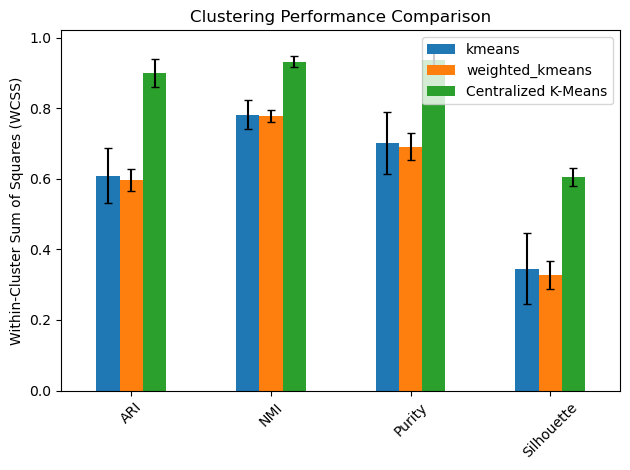

In [15]:
sim.plot_summary()

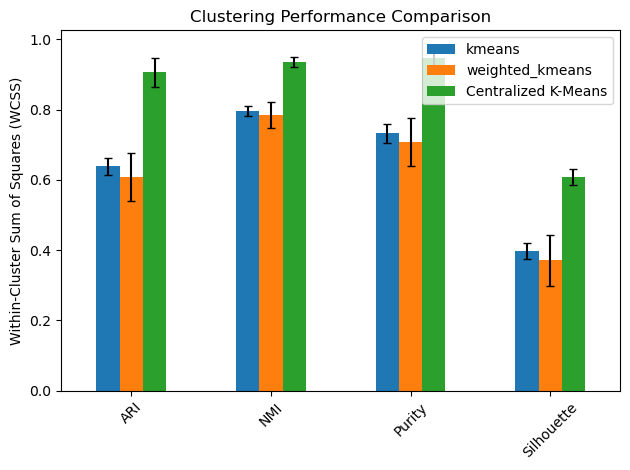

In [9]:
sim.plot_summary()

In [7]:
i = 0
visualize_centers(sim.clients_centers[i], sim.server_centers['weighted_kmeans'][i], sim.server_centers['kmeans'][i], sim.clients_weights[i])

In [1]:
from utils.read_data import read_s_dataset
import numpy as np
import pandas as pd
from simulation import Simulation

X, y = read_s_dataset(2)

sim = Simulation(X, y, {})
print(sim.run_trial(0))

/Users/yi/Desktop/Essay/utils/read_data.py:6: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  X = pd.read_csv(f'data/s-originals/s{s}.txt', header=None, sep='   ')
/Users/yi/Desktop/Essay/utils/read_data.py:7: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  y = pd.read_csv(


{'WCSS': np.float64(44746745568582.67), 'ARI': 0.6240459772625497, 'NMI': 0.8101758601704124, 'Purity': np.float64(0.6534), 'Silhouette': 0.48495463903235597}


In [2]:
from orchestrator import ExperimentOrchestrator


config_path = "config.yaml"

orch = ExperimentOrchestrator(config_path, X, y)

In [3]:
orch.run_all()


 Experiment: kmeans_comparison | n_runs=10
Run 1/10 (seed=42)
Run 2/10 (seed=43)
Run 3/10 (seed=44)
Run 4/10 (seed=45)
Run 5/10 (seed=46)
Run 6/10 (seed=47)
Run 7/10 (seed=48)
Run 8/10 (seed=49)
Run 9/10 (seed=50)
Run 10/10 (seed=51)

 Experiment: high_snr_test | n_runs=5
Run 1/5 (seed=42)
Run 2/5 (seed=43)
Run 3/5 (seed=44)
Run 4/5 (seed=45)
Run 5/5 (seed=46)

 Summary saved to `results/summary.pickle`
       experiment         WCSS                   ARI               NMI           Purity          Silhouette         
                          mean          std     mean      std     mean      std    mean      std       mean      std
    high_snr_test 4.002673e+13 2.085505e+12 0.650891 0.012420 0.825490 0.007635 0.66336 0.005094   0.500427 0.015373
kmeans_comparison 7.335027e+13 7.637086e+12 0.529728 0.026889 0.745183 0.016170 0.58184 0.028010   0.359063 0.035978


experiment          WCSS                     ARI            \
                              mean           std      mean       std   
0      high_snr_test  4.002673e+13  2.085505e+12  0.650891  0.012420   
1  kmeans_comparison  7.335027e+13  7.637086e+12  0.529728  0.026889   

        NMI             Purity           Silhouette            
       mean       std     mean       std       mean       std  
0  0.825490  0.007635  0.66336  0.005094   0.500427  0.015373  
1  0.745183  0.016170  0.58184  0.028010   0.359063  0.035978

In [20]:
d = pd.read_pickle('results/exp_20260414_231121.pkl')

In [62]:
d['summary'].drop('WCSS', axis=1, level=0).set_index('experiment').T.swaplevel()#.plot(kind='bar', y='mean', yerr='std', capsize=3)

,experiment,high_snr_test,kmeans_comparison
mean,ARI,0.650891,0.522220
std,ARI,0.012420,0.034369
mean,NMI,0.825490,0.742103
std,NMI,0.007635,0.020165
mean,Purity,0.663360,0.573720
std,Purity,0.005094,0.034487
mean,Silhouette,0.500427,0.340425
std,Silhouette,0.015373,0.031904


In [ ]:
def plot_summary(df):
    # self.stats['mean']['WCSS'].plot.bar(yerr=self.stats['std']['WCSS'])
    d['summary'].drop('WCSS', axis=1, level=0).set_index('experiment')plot(
        kind='bar', y='mean', yerr='std', capsize=3)
    plt.ylabel('Score')
    plt.title('Clustering Performance Comparison')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [24]:
plot_summary(d['summary'])

KeyError: 'mean'